# Adjoint

[Official documentation](https://qualtran.readthedocs.io/en/latest/Adjoint.html)

|0>


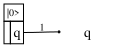

<0|


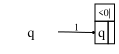

In [2]:
from qualtran.drawing import show_bloq
from qualtran.bloqs.basic_gates import ZeroState

print(ZeroState())
show_bloq(ZeroState())
print(ZeroState().adjoint())
show_bloq(ZeroState().adjoint())

### Interface

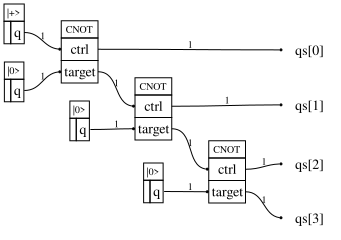

In [3]:
import numpy as np

from qualtran import BloqBuilder
from qualtran.bloqs.basic_gates import ZeroState, PlusState, CNOT

bb = BloqBuilder()
q0 = bb.add(PlusState())

src_q = q0
qvars = []
for _ in range(3):
    next_q = bb.add(ZeroState())
    src_q, next_q = bb.add(CNOT(), ctrl=src_q, target=next_q)

    qvars.append(src_q)
    src_q = next_q

qvars.append(src_q)
bell_cbloq = bb.finalize(qs=np.array(qvars))
show_bloq(bell_cbloq)

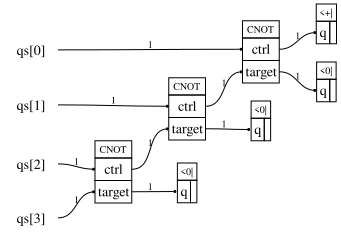

In [4]:
show_bloq(bell_cbloq.adjoint())

### Implementation

In [5]:
from qualtran.bloqs.basic_gates import CNOT, XGate

print(XGate() == XGate().adjoint())
print(CNOT() == CNOT().adjoint())

True
True


In [6]:
from qualtran.bloqs.mcmt import And
from qualtran.drawing import show_counts_sigma

_, forward_costs = And().call_graph()
_, backward_costs = And().adjoint().call_graph()
show_counts_sigma(forward_costs)
show_counts_sigma(backward_costs)

#### Counts totals:
 - `And`: 1

#### Counts totals:
 - `And†`: 1

### Default Fallback

In [7]:
from qualtran.bloqs.for_testing import TestSerialCombo

bloq = TestSerialCombo()
bloq.adjoint()

Adjoint(subbloq=TestSerialCombo())

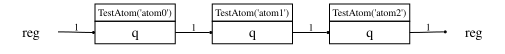

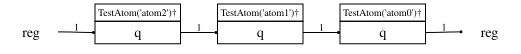

In [8]:
show_bloq(bloq.decompose_bloq())
show_bloq(bloq.adjoint().decompose_bloq())

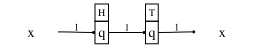

In [9]:
from functools import cached_property
from typing import *

from qualtran import BloqBuilder, Bloq, Signature, SoquetT
from qualtran.bloqs.basic_gates import  TGate, Hadamard

class TStateMaker(Bloq):
    @cached_property
    def signature(self) -> "Signature":
        return Signature.build(x=1)

    def build_composite_bloq(self, bb: 'BloqBuilder', x: 'SoquetT') -> Dict[str, 'SoquetT']:
        x = bb.add(Hadamard(), q=x)
        x = bb.add(TGate(), q=x)
        return {'x': x}
    
show_bloq(TStateMaker().decompose_bloq())

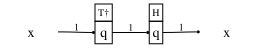

In [10]:
show_bloq(TStateMaker().adjoint().decompose_bloq())

### Additional Functionality